In [31]:
from dotenv import load_dotenv
load_dotenv(r"c:\Users\Admin\hipython\learning\llm\.env", override=True)
import os
from langgraph.graph import StateGraph, END, START
from typing import TypedDict, List
from langchain_core.documents import Document
from langchain_openai import OpenAIEmbeddings, ChatOpenAI
from langchain_pinecone import PineconeVectorStore
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

In [32]:
# LLM 초기화
llm    = ChatOpenAI(model="gpt-4o-mini", temperature=0)
parser = StrOutputParser()

# Pinecone 연결
embeddings  = OpenAIEmbeddings(model="text-embedding-3-small")
vectorstore = PineconeVectorStore.from_existing_index(
    index_name="finance-bok",
    embedding=embeddings,
    namespace="bok-ns1"
)
retriever = vectorstore.as_retriever(
    search_kwargs={"k": 3, "namespace": "bok-ns1"}
)

print("초기화 완료")

초기화 완료


## MRAG 파이프라인 실습

### 전체 파이프라인 구조

```text
Query
  ↓
Rewrite            ← 질문을 검색에 최적화된 형태로 재작성
  ↓
Retrieve           ← Pinecone에서 관련 문서 검색
  ↓
Grade              ← 검색된 문서의 품질 평가
  ├─ good            → Generate → 답변 출력
  ├─ bad (retry < 2)  → Rewrite Retry → Retrieve
  └─ bad (retry >= 2) → Fallback → 경고 포함 답변 출력
```

### 데이터 및 환경 정보

| 항목 | 내용 |
| --- | --- |
| 문서 | 2026년 2월 한국은행 경제전망보고서 |
| 벡터 DB | Pinecone (`finance-bok` / `bok-ns1`) |
| 임베딩 | `text-embedding-3-small` (1536차원) |
| LLM | `gpt-4o-mini` (`temperature=0`) |
| 그래프 프레임워크 | LangGraph 1.1.6 |

### 실습 포인트

- `06_finance_RAG.ipynb`에서 만든 Pinecone retriever를 그대로 재사용합니다.
- `07_MRAG.ipynb`의 `StateGraph` 구조를 가져와, 금융 보고서 질의에 맞게 `rewrite -> retrieve -> grade -> generate/fallback` 흐름으로 구성합니다.
- 각 노드 함수에는 한국어 주석과 docstring을 달아, 수업용으로 읽기 쉬운 형태로 정리합니다.


### 1. 상태 정의

MRAG 흐름에서 공유할 상태를 먼저 정의합니다.


In [33]:
from typing import Literal, TypedDict

from langchain_core.documents import Document


### 2. 상태 스키마

질문, 검색 결과, 품질 판정, 답변, 재시도 횟수를 한 곳에서 관리합니다.


In [34]:
# MRAG 전체 상태를 정의합니다.
class FinanceMRAGState(TypedDict, total=False):
    query: str
    rewritten_query: str
    docs: list[Document]
    grade: str
    grade_reason: str
    answer: str
    retry_count: int


### 3. 품질 판정 스키마

검색 품질을 `good` 또는 `bad`로 받기 위한 구조화 스키마입니다.


In [35]:
from pydantic import BaseModel, Field


# LLM이 반환할 품질 판정 형식입니다.
class RetrievalGrade(BaseModel):
    decision: Literal["good", "bad"] = Field(description="검색 품질 결과")
    reason: str = Field(description="판정 이유")


### 4. 공통 객체 준비

앞에서 만든 retriever를 그대로 재사용하고, 문자열 파서도 함께 준비합니다.


In [36]:
from langchain_core.output_parsers import StrOutputParser


# 06 노트북에서 만든 retriever를 그대로 사용합니다.
if "retriever" not in globals():
    raise ValueError("먼저 Retriever 생성 셀을 실행해주세요.")

mrag_retriever = retriever
mrag_text_parser = StrOutputParser()


### 5. 재작성 프롬프트

사용자 질문을 검색용 질의로 다시 쓰는 단계입니다.


In [37]:
from langchain_core.prompts import ChatPromptTemplate


# 질문을 검색 친화적으로 바꿉니다.
mrag_rewrite_prompt = ChatPromptTemplate.from_template(
    """
당신은 한국은행 경제전망보고서 검색을 돕는 질의 재작성기입니다.
사용자 질문을 Pinecone 검색에 더 적합한 한국어 질의 1문장으로 다시 써주세요.

작성 원칙:
- 시점, 수치, 핵심 항목을 유지합니다.
- retry_count가 증가하면 더 구체한 키워드를 넣습니다.
- 설명 없이 재작성된 질의만 출력합니다.

[질문]
{query}

[retry_count]
{retry_count}
"""
)


### 6. 품질 평가 프롬프트

검색된 문서가 바로 답변 생성에 쓸 수 있는지 판정합니다.


In [38]:
# 검색 품질을 good / bad로 판정합니다.
mrag_grade_prompt = ChatPromptTemplate.from_template(
    """
당신은 검색 품질 평가자입니다.
사용자 질문과 검색 문서를 보고, 바로 답변 생성에 쓰여도 될지 판정해주세요.

판정 기준:
- good: 근거 문장이 분명히 있음
- bad: 근거가 부족하거나 관련성이 낮음

[질문]
{query}

[재작성 질의]
{rewritten_query}

[검색 문서]
{context}
"""
)


### 7. 생성 프롬프트

품질 판정이 좋은 경우에 사용할 답변 프롬프트입니다.


In [39]:
# 근거가 충분할 때 일반 답변을 생성합니다.
mrag_generate_prompt = ChatPromptTemplate.from_template(
    """
당신은 한국은행 경제전망 보고서를 기반으로 답변하는 금융 전문 어시스턴트입니다.
참고문서를 바탕으로 간결하고 정확하게 답하세요.
- 수치는 단위까지 포함합니다.
- 문서에 없는 내용은 "보고서에서 확인되지 않습니다"라고 답합니다.

[질문]
{query}

[재작성 질의]
{rewritten_query}

[참고문서]
{context}
"""
)


### 8. Fallback 프롬프트

재시도 후에도 품질이 부족할 때 사용할 프롬프트입니다.


In [40]:
# 경고 문구를 포함한 보수적 답변을 생성합니다.
mrag_fallback_prompt = ChatPromptTemplate.from_template(
    """
당신은 한국은행 경제전망 보고서를 기반으로 답변하는 금융 전문 어시스턴트입니다.
이번 경우는 검색 품질이 충분하지 않아 답변 신뢰도가 낮습니다.
가능하면 근거 내에서만 조심스럽게 답하고, 맨 앞에 "[경고: 검색 근거가 제한적입니다]"를 붙여주세요.
문서에 없는 내용은 "보고서에서 확인되지 않습니다"라고 답합니다.

[질문]
{query}

[재작성 질의]
{rewritten_query}

[참고문서]
{context}
"""
)


### 9. 체인 연결

프롬프트와 LLM을 연결해 실제 실행 체인으로 만듭니다.


In [41]:
# 프롬프트를 실행 체인으로 만듭니다.
mrag_rewrite_chain = mrag_rewrite_prompt | llm | mrag_text_parser
mrag_grade_chain = mrag_grade_prompt | llm.with_structured_output(RetrievalGrade)
mrag_generate_chain = mrag_generate_prompt | llm | mrag_text_parser
mrag_fallback_chain = mrag_fallback_prompt | llm | mrag_text_parser


### 10. 문서 포맷 함수

검색된 `Document` 목록을 프롬프트에 넣기 좋은 문자열로 바꿉니다.


In [42]:
# Document 목록을 문자열로 만듭니다.
def format_docs_for_mrag(documents: list[Document]) -> str:
    """문서 목록을 프롬프트용 문자열로 바꿉니다."""
    if not documents:
        return ""

    return "\n\n".join(
        f"[p.{doc.metadata.get('page', '')}] {doc.page_content}"
        for doc in documents
    )


### 11. Rewrite 노드

첫 번째 노드는 사용자 질문을 검색용 질의로 바꿉니다.


In [43]:
# 원래 질문을 검색용 질의로 바꿉니다.
def rewrite_node(state: FinanceMRAGState):
    """질문을 검색에 맞게 재작성합니다."""
    retry_count = state.get("retry_count", 0)
    rewritten_query = mrag_rewrite_chain.invoke(
        {"query": state["query"], "retry_count": retry_count}
    )
    return {"rewritten_query": rewritten_query.strip(), "retry_count": retry_count}


### 12. Rewrite Retry 노드

품질이 낮으면 질문을 더 구체화해 한 번 더 검색합니다.


In [44]:
# 질문을 더 구체화해 재작성합니다.
def rewrite_retry_node(state: FinanceMRAGState):
    """retry_count를 증가시킨 후 다시 질의합니다."""
    next_retry = state.get("retry_count", 0) + 1
    rewritten_query = mrag_rewrite_chain.invoke(
        {"query": state["query"], "retry_count": next_retry}
    )
    return {"rewritten_query": rewritten_query.strip(), "retry_count": next_retry}


### 13. Retrieve 노드

재작성된 질의로 Pinecone에서 관련 문서를 가져옵니다.


In [45]:
# Pinecone에서 관련 문서를 검색합니다.
def retrieve_node(state: FinanceMRAGState):
    """재작성된 질의로 문서를 검색합니다."""
    retrieved_docs = mrag_retriever.invoke(state["rewritten_query"])
    return {"docs": retrieved_docs}


### 14. Grade 노드

검색된 문서가 충분한지 판정하고, 이유도 함께 저장합니다.


In [46]:
# 검색 품질을 판정합니다.
def grade_node(state: FinanceMRAGState):
    """good / bad 결과와 이유를 만듭니다."""
    context = format_docs_for_mrag(state.get("docs", []))

    if not context:
        return {"grade": "bad", "grade_reason": "검색된 문서가 없습니다."}

    grade_result = mrag_grade_chain.invoke(
        {
            "query": state["query"],
            "rewritten_query": state["rewritten_query"],
            "context": context,
        }
    )
    return {"grade": grade_result.decision, "grade_reason": grade_result.reason}


### 15. Generate 노드

품질이 좋은 경우에는 일반 답변 생성 체인으로 최종 답변을 만듭니다.


In [47]:
# 일반 답변을 생성합니다.
def generate_node(state: FinanceMRAGState):
    """근거가 충분할 때 생성 체인을 사용합니다."""
    answer = mrag_generate_chain.invoke(
        {
            "query": state["query"],
            "rewritten_query": state["rewritten_query"],
            "context": format_docs_for_mrag(state.get("docs", [])),
        }
    )
    return {"answer": answer}


### 16. Fallback 노드

재시도 후에도 품질이 부족할 때는 경고문을 포함한 답변을 내보냅니다.


In [48]:
# 경고 문구를 포함한 fallback 답변을 만듭니다.
def fallback_node(state: FinanceMRAGState):
    """검색 근거가 약할 때 보수적으로 답합니다."""
    context = format_docs_for_mrag(state.get("docs", []))

    if not context:
        return {"answer": "[경고: 검색 근거가 제한적입니다] 보고서에서 확인되지 않습니다."}

    answer = mrag_fallback_chain.invoke(
        {
            "query": state["query"],
            "rewritten_query": state["rewritten_query"],
            "context": context,
        }
    )
    return {"answer": answer}


### 17. 라우터 함수

`grade` 결과와 `retry_count`를 보고 다음 노드를 정합니다.


In [49]:
# 다음 노드를 선택합니다.
def route_after_grade(state: FinanceMRAGState) -> str:
    """good, retry 횟수에 따라 다음 단계를 결정합니다."""
    if state.get("grade") == "good":
        return "generate"

    if state.get("retry_count", 0) < 2:
        return "rewrite_retry"

    return "fallback"


### 18. 그래프 구성

지금까지 만든 노드를 LangGraph에 연결해 전체 MRAG 흐름을 완성합니다.


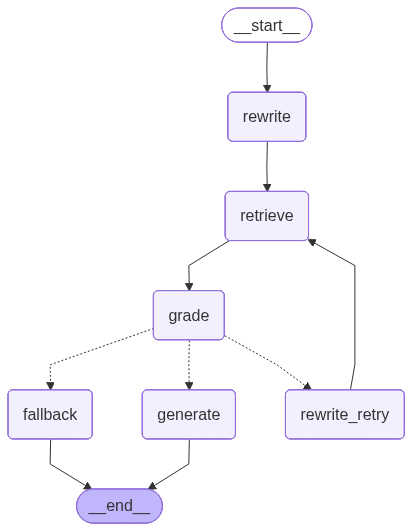

In [50]:
# MRAG 그래프를 구성합니다.
from langgraph.graph import END, START, StateGraph

finance_mrag_graph = StateGraph(FinanceMRAGState)

finance_mrag_graph.add_node("rewrite", rewrite_node)
finance_mrag_graph.add_node("rewrite_retry", rewrite_retry_node)
finance_mrag_graph.add_node("retrieve", retrieve_node)
finance_mrag_graph.add_node("grade", grade_node)
finance_mrag_graph.add_node("generate", generate_node)
finance_mrag_graph.add_node("fallback", fallback_node)

finance_mrag_graph.add_edge(START, "rewrite")
finance_mrag_graph.add_edge("rewrite", "retrieve")
finance_mrag_graph.add_edge("retrieve", "grade")
finance_mrag_graph.add_conditional_edges(
    "grade",
    route_after_grade,
    {
        "generate": "generate",
        "rewrite_retry": "rewrite_retry",
        "fallback": "fallback",
    },
)
finance_mrag_graph.add_edge("rewrite_retry", "retrieve")
finance_mrag_graph.add_edge("generate", END)
finance_mrag_graph.add_edge("fallback", END)

finance_mrag_app = finance_mrag_graph.compile()
finance_mrag_app


### 19. 테스트 실행

마지막으로 실제 질문을 넣고 MRAG 파이프라인을 실행해봅니다.


In [51]:
mrag_test_questions = [
    "2026년 GDP 성장률 전망치는 얼마인가요?",
    "2026년 수출 전망 금액은 얼마인가요?",
    "부문별 온도차가 발생하는 이유는?",
    "미국 연방준비제도의 금리 결정 일정은?",
]

for question in mrag_test_questions:
    final_state = finance_mrag_app.invoke({"query": question, "retry_count": 0})

    print("=" * 90)
    print(f"[질문] {question}")
    print(f"[재작성 질의] {final_state.get('rewritten_query', '')}")
    print(f"[품질 판정] {final_state.get('grade', '')} / {final_state.get('grade_reason', '')}")
    print(f"[재시도 횟수] {final_state.get('retry_count', 0)}")

    docs_for_display = final_state.get("docs", [])
    for i, doc in enumerate(docs_for_display[:3], start=1):
        snippet = doc.page_content.replace("\n", " ")
        print(f"  - 근거 {i}: (p.{doc.metadata.get('page', '')}) {snippet[:120]}")

    print(f"[최종 답변] {final_state.get('answer', '')}")
    print()


[질문] 2026년 GDP 성장률 전망치는 얼마인가요?
[재작성 질의] 2026년 GDP 성장률 전망치는 얼마인지 알려주세요.
[품질 판정] good / 검색 문서에서 2026년 GDP 성장률이 2.0%로 명확하게 제시되어 있어, 질문에 대한 답변으로 적합하다.
[재시도 횟수] 0
  - 근거 1: (p.43.0) 30    <경제성장 전망1)>  (전년동기대비, %)    2024 2025 2026e) 2027e)  연간 상반 하반 연간 상반 하반 연간 연간  GDP 성장률 2.0 0.3 1.6 1.0 2.4 1.6 2.0 
  - 근거 2: (p.79.0) 66    한국은행 전망에서는 점진적∙보수적인 전망 경향이 나타남   [그림3] 분기별 GDP 성장률1) 및 전망 [그림4] 분기성장률(전년동기대비) 증감과 전망오차2)        주: 1) 속보치 기준      
  - 근거 3: (p.9.0) ▪ 27년에는 내수 회복세가 지속되는 가운데 수출도 세계경제 성장세 지속, 반도체  공급능력 확충 등으로 증가하며 1.8%의 견조한 성장세를 나타낼 전망이다.        <국내 성장률 전망1)> <국내 GDP 전망
[최종 답변] 2026년 GDP 성장률 전망치는 2.0%입니다.

[질문] 2026년 수출 전망 금액은 얼마인가요?
[재작성 질의] 2026년 수출 전망 금액은 얼마인지 알려주세요.
[품질 판정] good / 검색 문서에서 2026년 수출 전망 금액이 7,952로 명확하게 제시되어 있어, 질문에 대한 근거가 분명하다.
[재시도 횟수] 0
  - 근거 1: (p.45.0) 32    <경상수지 전망1)>  (전년동기대비, %)    2024 2025 2026e) 2027e)  연간 상반 하반 연간 상반 하반 연간 연간  경상수지 1,000 479 752 1,231 863 837 1,7
  - 근거 2: (p.11.0) < 요약 6/8 >  6      전망의 리스크     향후 성장 전망경로에는 반도체 경기, 글로벌 통상환경, 국제금융시장 등과 관